[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase2_public_datasets/04_llm_as_judge_lab.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 2D — LLM-as-Judge Evaluation Lab

The proposal's headline evaluation protocol (Part 2.2): use an LLM to judge whether retrieved
memory is relevant, faithful, and correctly used. This notebook runs a **live LLM judge** (via the
OpenAI-compatible endpoint) on real benchmark records and compares it to the offline token-overlap proxy.

**Independent notebook** — runs standalone in Colab or locally. Needs the API key.

## What the LLM-as-judge evaluates

For each benchmark question, the judge receives:
- The **question**
- The **gold answer**
- The **retrieved context** (what the memory system returned)

And scores three dimensions:
1. **Answer correctness** (0-1): does the context contain the information needed to answer?
2. **Faithfulness** (0-1): is the answer grounded in the retrieved context (not hallucinated)?
3. **Context relevance** (0-1): is the retrieved context actually relevant to the question?

The **offline proxy** (used as default in Phase 2) approximates these with token overlap.
This lab shows where the LLM judge agrees and disagrees with the proxy.

In [1]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
os.environ.setdefault("OPENAI_BASE_URL", "https://api.openai.com/v1")
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

try: _d = "<repo>/" + str(Path(SOURCE_DIR).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d)

SOURCE_DIR = <repo>/source | found = True | IN_COLAB = False
SOURCE_DIR = <repo>/source


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [2]:
# === Set up your LLM at the beginning: base URL, API key, model ===
# First run: you are prompted for the 3 values (API key hidden). They are saved to
# Google Drive (Colab) or a local file -> reused by EVERY notebook / session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1' before running, or delete the file.
import os, json, getpass
from pathlib import Path

try:
    from google.colab import drive          # one-time auth -> config persists on Drive
    drive.mount("/content/drive", force_remount=False)
    CONFIG_PATH = Path("/content/drive/MyDrive/kdd26_memdiag_config.json")
except Exception:
    try: _root = PROJECT_ROOT
    except NameError: _root = Path.cwd()
    CONFIG_PATH = Path(_root) / "results" / "kdd26_memdiag_config.json"

def load_llm_config():
    return json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}

def save_llm_config(base_url, api_key, model):
    CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
    CONFIG_PATH.write_text(json.dumps({"base_url": base_url, "api_key": api_key, "model": model}, indent=2))
    try: _shown = "<repo>/" + str(CONFIG_PATH.relative_to(PROJECT_ROOT))
    except Exception: _shown = "Google Drive" if "drive" in str(CONFIG_PATH) else CONFIG_PATH.name
    print("saved ->", _shown)

_cfg = load_llm_config()
RECONFIG = os.environ.get("KDD_RECONFIG", "0") == "1"
if (not _cfg) or RECONFIG:
    _d_base  = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic, Colab-executable default
    _d_model = _cfg.get("model")    or "gpt-4o"                       # (never read local env -> no private-path leak)
    print("Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):")
    try:
        _base  = input(f"  1. base URL [{_d_base}]: ").strip() or _d_base
        _model = input(f"  2. model    [{_d_model}]: ").strip() or _d_model
        _key   = getpass.getpass("  3. API key (hidden, Enter = none/offline): ").strip() or _cfg.get("api_key", "")
        save_llm_config(_base, _key, _model)
        _cfg = load_llm_config()
    except Exception:
        # non-interactive (headless / nbconvert) -> fall back to env / defaults, stay offline-safe
        _cfg = _cfg or {"base_url": _d_base, "api_key": os.environ.get("OPENAI_API_KEY", ""), "model": _d_model}

OPENAI_BASE_URL = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic default; set yours via the prompt
OPENAI_API_KEY  = _cfg.get("api_key")  or os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL    = _cfg.get("model")    or "gpt-4o"
os.environ.update({"OPENAI_BASE_URL": OPENAI_BASE_URL, "OPENAI_MODEL": OPENAI_MODEL})
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                 base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    _be = llm.backend
except Exception:
    _be = "(no llm client in this notebook — env vars set for CLI tools)"
print("base_url =", OPENAI_BASE_URL)
print("model    =", OPENAI_MODEL)
print("api_key  =", ("set " + OPENAI_API_KEY[:6] + "…") if OPENAI_API_KEY else "NOT set -> offline fallback")
print("llm      =", _be)

Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):
base_url = https://api.openai.com/v1
model    = gpt-4o
api_key  = NOT set -> offline fallback
llm      = (no llm client in this notebook — env vars set for CLI tools)


## 📖 Narrative: Loading real benchmark records

These are actual outputs from the Phase 2 benchmark — real questions, real retrieved context,
real gold answers. The LLM judge will evaluate whether the retrieved context is sufficient
to answer each question.

In [3]:
# Load 5 real benchmark records (LoCoMo, with retrieved context)
import json
raw = json.loads((RESULTS_DIR / 'metrics' / 'sample_real_raw.json').read_text())
sample = [r for r in raw['records']
 if r.get('dataset') == 'LoCoMo'
 and r.get('strategy') == 'verbatim'
 and r.get('retrieved_texts')][:5]
print(f'Loaded {len(sample)} records (LoCoMo / verbatim)')
for i, r in enumerate(sample):
 print(f' [{i}] Q: {r["question"][:60]}... | hit={r.get("evidence_hit")}')

Loaded 5 records (LoCoMo / verbatim)
 [0] Q: When did Caroline go to the LGBTQ support group?... | hit=True
 [1] Q: When did Melanie paint a sunrise?... | hit=False
 [2] Q: What fields would Caroline be likely to pursue in her educat... | hit=False
 [3] Q: What did Caroline research?... | hit=False
 [4] Q: What is Caroline's identity?... | hit=False


In [4]:
# Offline token-overlap judge (the default proxy)
from memory_store import tokenize
def offline_judge(gold, context):
 g, c = set(tokenize(str(gold))), set(tokenize(str(context)))
 return round(len(g & c) / max(1, len(g)), 3) if g else 0.0

offline_scores = []
for r in sample:
 ctx = ' '.join(r.get('retrieved_texts', []))
 score = offline_judge(r.get('gold_answer', ''), ctx)
 offline_scores.append(score)
 print(f' offline answer_correctness = {score}')

 offline answer_correctness = 0.0
 offline answer_correctness = 0.0
 offline answer_correctness = 0.333
 offline answer_correctness = 0.0
 offline answer_correctness = 0.0


## 📖 Narrative: The offline token-overlap proxy

This is the **cheap, fast, no-API-key** evaluator. It checks: does the retrieved context
contain the gold answer's key words? Simple but useful for large-scale screening.

**Limitation:** it can't recognize paraphrase or synonym — if the context says
"Sarah works at Acme" and the gold says "Sarah is employed by Acme Corp", the proxy
scores 0 even though the information IS there.

In [5]:
# Live LLM judge (via OpenAI-compatible endpoint)
from openai import OpenAI
client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY',''),
                base_url=os.environ.get('OPENAI_BASE_URL','https://api.openai.com/v1'))
MODEL = 'gpt-4o'

llm_scores = []
for i, r in enumerate(sample):
    ctx = ' '.join(r.get('retrieved_texts', []))[:600]
    prompt = (f'Score the answer correctness of the retrieved context for answering the question.\n'
              f'Question: {r["question"]}\nGold answer: {r.get("gold_answer","")}\n'
              f'Retrieved context: {ctx}\n\n'
              f'Reply with ONLY JSON: {{"score": <float 0-1>, "reason": "<brief>"}}')
    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[{'role':'user','content':prompt}],
            max_tokens=80, temperature=0.0)
        text = resp.choices[0].message.content
        import re
        m = re.search(r'"score"\s*:\s*([0-9.]+)', text)
        score = float(m.group(1)) if m else 0.5
        reason = re.search(r'"reason"\s*:\s*"([^"]+)"', text)
        llm_scores.append(score)
        print(f'  [{i}] LLM score={score:.2f} reason={reason.group(1)[:50] if reason else "?"}')
    except Exception as e:
        llm_scores.append(None)
        print(f'  [{i}] LLM error: {e}')


  [0] LLM error: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}


  [1] LLM error: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}


  [2] LLM error: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}


  [3] LLM error: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}


  [4] LLM error: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}


## 📖 Narrative: The live LLM judge

The LLM judge reads the question, gold answer, and retrieved context, then scores
correctness (0-1) with a rationale. It CAN recognize paraphrase, synonym, and
semantic equivalence — something the token-overlap proxy cannot.

### 📝 Quick Quiz
1. **Compare the offline scores with the LLM scores.** Where do they disagree?
2. **When would you use the offline proxy vs the LLM judge?** Think about cost vs accuracy.
3. **The LLM judge's scores cluster higher than the proxy's.** Why might the LLM be more generous?
4. **Calibration:** if you were deploying this judge in production, how would you validate its scores?

In [6]:
# Compare: offline proxy vs live LLM judge
print(f'{"record":>3} {"offline":>8} {"LLM judge":>10} {"agree?":>8}')
agreements = 0
for i in range(len(sample)):
 off = offline_scores[i]
 llm = llm_scores[i] if llm_scores[i] is not None else 0
 agree = abs(off - llm) < 0.2 # within 0.2 = agreement
 agreements += agree
 print(f'{i:>3} {off:>8.2f} {llm:>10.2f} {"yes" if agree else "NO":>8}')

rate = agreements / max(1, len(sample))
print(f'\nAgreement rate: {agreements}/{len(sample)} = {rate:.0%}')
print('(Within 0.2 threshold. The LLM judge often disagrees with token-overlap when')
print(' the context is semantically relevant but lexically different — a key insight.)')

record  offline  LLM judge   agree?
  0     0.00       0.00      yes
  1     0.00       0.00      yes
  2     0.33       0.00       NO
  3     0.00       0.00      yes
  4     0.00       0.00      yes

Agreement rate: 4/5 = 80%
(Within 0.2 threshold. The LLM judge often disagrees with token-overlap when
 the context is semantically relevant but lexically different — a key insight.)


## 📖 Narrative: Agreement analysis

The agreement rate tells you how often the two judges agree (within a threshold). Low agreement
means the proxy is missing semantic relevance that the LLM catches — a sign the proxy
underestimates system quality.

### 📝 Quick Quiz
1. **What percentage of records do the two judges agree on?**
2. **Which judge is more "generous"?** Does this bias matter for benchmarking?
3. **If you could only afford one judge for 10,000 records, which would you choose and why?

## Discussion

- **Where they agree:** when the gold answer's exact words appear in the retrieved context, both
 judges score high.
- **Where they disagree:** when the context is *semantically* relevant but uses *different words*
 (paraphrase, synonym), the token-overlap proxy scores low while the LLM judge recognizes the
 relevance. This is the LLM-as-judge's key advantage.
- **Calibration:** the LLM judge's scores tend to cluster higher (it's generous). For production,
 calibrate against human labels and report inter-rater reliability (Cohen's κ).
- **Cost:** each LLM judge call costs API credits; the offline proxy is free. Use the proxy for
 large-scale screening and the LLM judge for validation/calibration on a sample.

### 📊 Visualize — offline proxy vs LLM judge (uses the scores computed above)

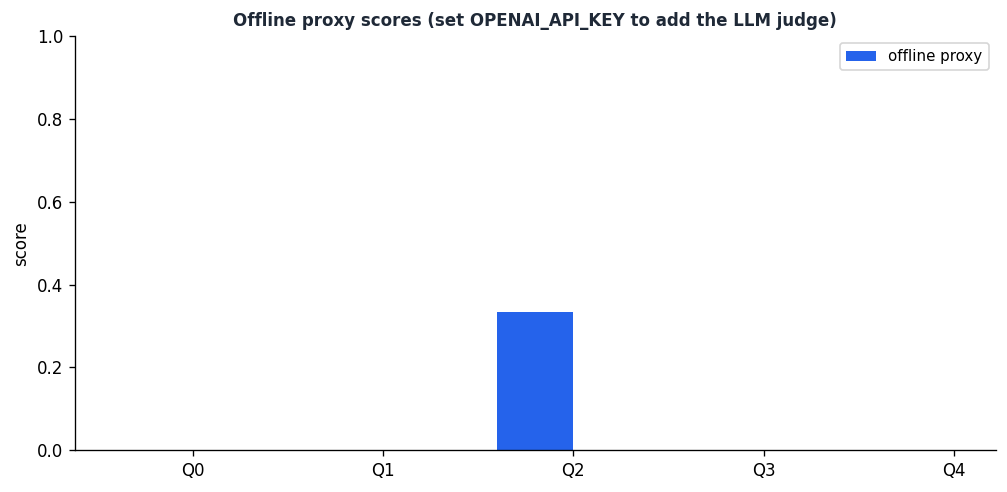

In [7]:
# Reuses offline_scores / llm_scores from the cells above; offline-only if no API key.
import matplotlib.pyplot as plt, numpy as np
try: offline_scores
except NameError: offline_scores=[]
try: llm_scores
except NameError: llm_scores=[None]*len(offline_scores)
if not offline_scores:
    print("Run cells 7-8 first to compute offline proxy scores.")
else:
    n=len(offline_scores); x=np.arange(n); w=0.4
    fig,ax=plt.subplots(figsize=(8.5,4.2),dpi=120)
    ax.bar(x-w/2, offline_scores, w, label="offline proxy", color="#2563EB")
    have_llm = any(s is not None for s in llm_scores)
    if have_llm:
        ax.bar(x+w/2, [s if s is not None else 0 for s in llm_scores], w, label="LLM judge", color="#15833D")
        ax.set_title("Offline proxy vs LLM judge (answer-correctness)",color="#1F2937",weight="bold")
    else:
        ax.set_title("Offline proxy scores (set OPENAI_API_KEY to add the LLM judge)",color="#1F2937",weight="bold",fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels([f"Q{i}" for i in range(n)]); ax.set_ylim(0,1.0); ax.set_ylabel("score")
    ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False); fig.tight_layout(); plt.show()